### Testing Histolab Features

This code base will setup histolab and extract the tiles from WSI

In [ ]:
import os
from histolab.slide import Slide

Reading the slide using Histolab and convert into patches

In [4]:
from histolab.data import prostate_tissue, ovarian_tissue

In [5]:
prostate_svs, prostate_path = prostate_tissue()
ovarian_svs, ovarian_path = ovarian_tissue()

In [6]:
BASE_PATH = os.getcwd()

PROCESS_PATH_PROSTATE = os.path.join(BASE_PATH, 'prostate', 'processed')
PROCESS_PATH_OVARIAN = os.path.join(BASE_PATH, 'ovarian', 'processed')

prostate_slide = Slide(prostate_path, processed_path=PROCESS_PATH_PROSTATE)
ovarian_slide = Slide(ovarian_path, processed_path=PROCESS_PATH_OVARIAN)

In [7]:
print(f"Slide name: {prostate_slide.name}")
print(f"Levels: {prostate_slide.levels}")
print(f"Dimensions at level 0: {prostate_slide.dimensions}")
print(f"Dimensions at level 1: {prostate_slide.level_dimensions(level=1)}")
print(f"Dimensions at level 2: {prostate_slide.level_dimensions(level=2)}")

Slide name: TCGA-CH-5753-01A-01-BS1.4311c533-f9c1-4c6f-8b10-922daa3c2e3e
Levels: [0, 1, 2]
Dimensions at level 0: (16000, 15316)
Dimensions at level 1: (4000, 3829)
Dimensions at level 2: (2000, 1914)


In [8]:
print(f"Slide name: {ovarian_slide.name}")
print(f"Levels: {ovarian_slide.levels}")
print(f"Dimensions at level 0: {ovarian_slide.dimensions}")
print(f"Dimensions at level 1: {ovarian_slide.level_dimensions(level=1)}")
print(f"Dimensions at level 2: {ovarian_slide.level_dimensions(level=2)}")

Slide name: TCGA-13-1404-01A-01-TS1.cecf7044-1d29-4d14-b137-821f8d48881e
Levels: [0, 1, 2]
Dimensions at level 0: (30001, 33987)
Dimensions at level 1: (7500, 8496)
Dimensions at level 2: (1875, 2124)


In [9]:
print("Native magnification factor:", prostate_slide.level_magnification_factor())

print("Magnification factor corresponding to level 1:", prostate_slide.level_magnification_factor(level=1))

Native magnification factor: 20.0X
Magnification factor corresponding to level 1: 5.0X


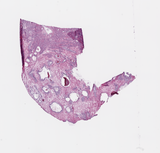

In [10]:
prostate_slide.thumbnail

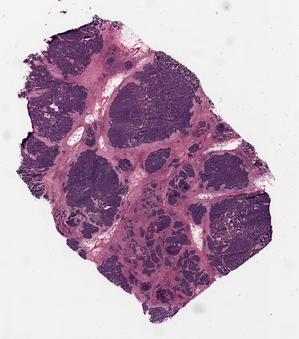

In [11]:
ovarian_slide.thumbnail

In [12]:
from histolab.tiler import RandomTiler

In [13]:
random_tiles_extractor = RandomTiler(
    tile_size=(224, 224),
    n_tiles=30,
    level=2,
    seed=42,
    check_tissue=True, # default
    tissue_percent=80.0, # default
    prefix="random/", # save tiles in the "random" subdirectory of slide's processed_path
    suffix=".png" # default
)

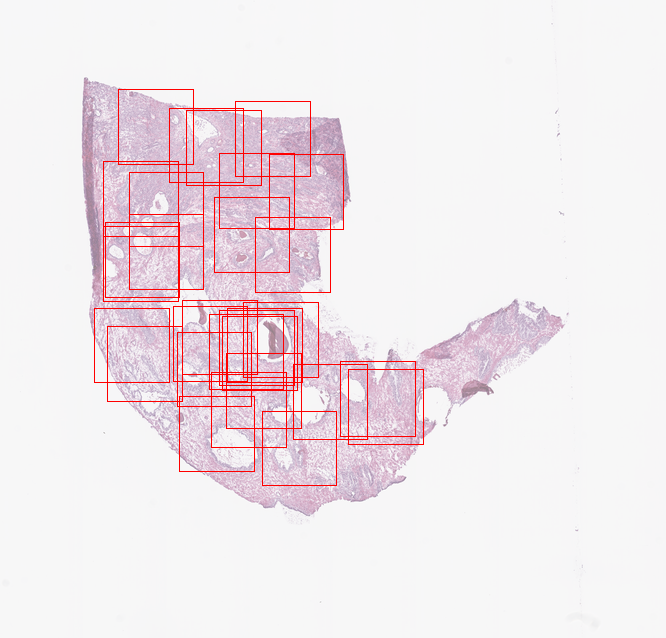

In [14]:
random_tiles_extractor.locate_tiles(
    slide=prostate_slide,
    scale_factor=24,  # default
    alpha=128,  # default
    outline="red",  # default
)

In [15]:
random_tiles_extractor.extract(prostate_slide)

In [16]:
from histolab.tiler import GridTiler

In [17]:
grid_tiles_extractor = GridTiler(
   tile_size=(224, 224),
   level=0,
   check_tissue=True, # default
   pixel_overlap=0, # default
   prefix="grid/", # save tiles in the "grid" subdirectory of slide's processed_path
   suffix=".png" # default
)

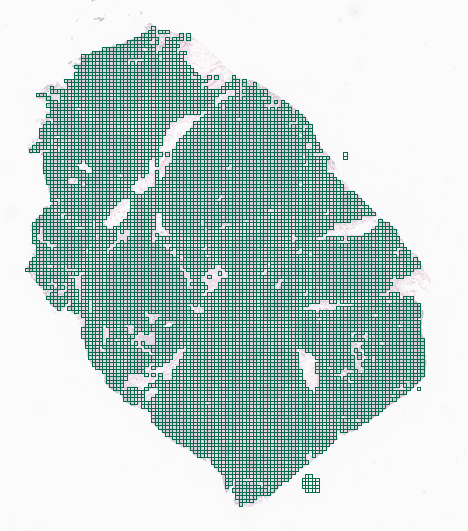

In [18]:
grid_tiles_extractor.locate_tiles(
    slide=ovarian_slide,
    scale_factor=64,
    alpha=64,
    outline="#046C4C",
)

In [19]:
grid_tiles_extractor.extract(ovarian_slide)

In [20]:
from histolab.tiler import ScoreTiler
from histolab.scorer import NucleiScorer

In [ ]:
scored_tiles_extractor = ScoreTiler(
    scorer = NucleiScorer(),
    tile_size=(224, 224),
    n_tiles=100,
    level=0,
    check_tissue=True,
    tissue_percent=80.0,
    pixel_overlap=0, # default
    prefix="scored/", # save tiles in the "scored" subdirectory of slide's processed_path
    suffix=".png" # default
)

/data/mn27889/miniconda3/envs/path-agents/lib/python3.10/site-packages/histolab/filters/image_filters_functional.py:210: UserWarning: Input image must be RGB. NOTE: the image will be converted to RGB before HED conversion.
  hed = rgb_to_hed(img)


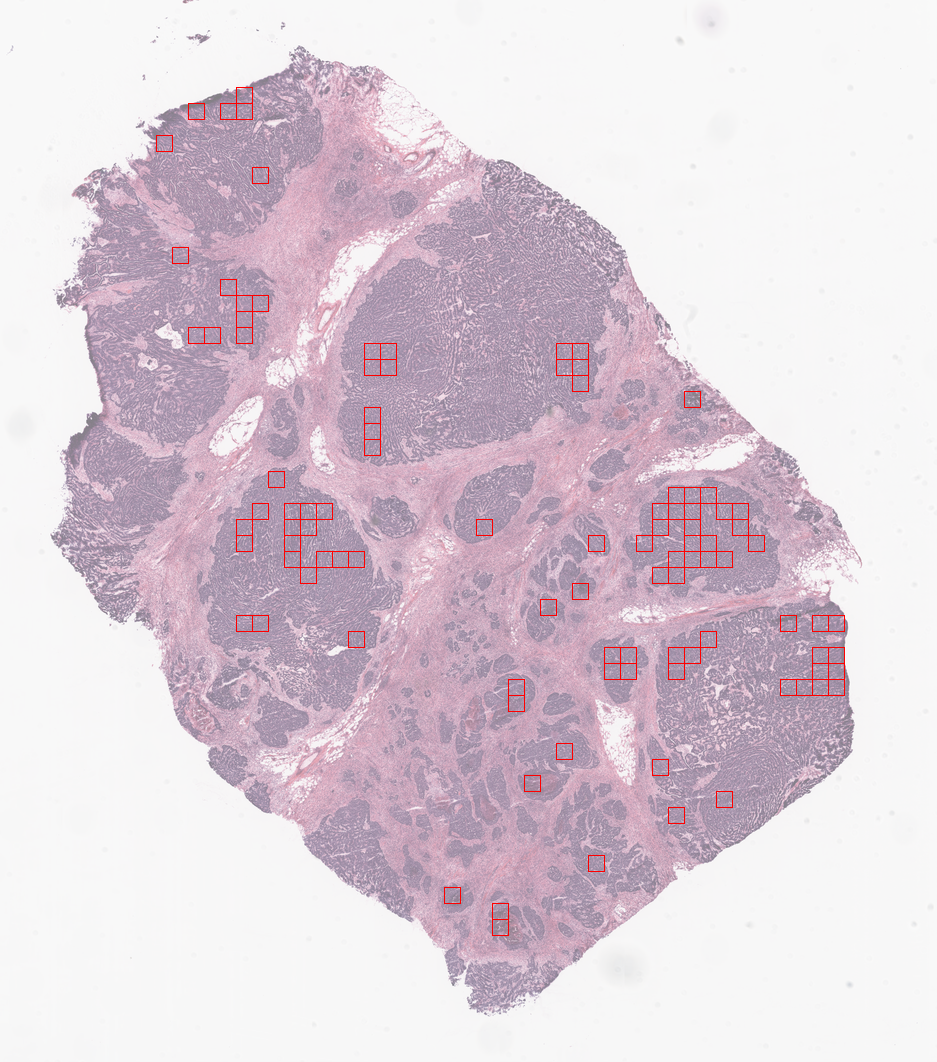

In [23]:
scored_tiles_extractor.locate_tiles(slide=ovarian_slide)

In [24]:
summary_filename = "summary_ovarian_tiles.csv"
SUMMARY_PATH = os.path.join(ovarian_slide.processed_path, summary_filename)

scored_tiles_extractor.extract(ovarian_slide, report_path=SUMMARY_PATH)